# Classification results

In [1]:
import pandas as pd
import numpy as np

import glob
import string
letters = list(string.ascii_lowercase)

import matplotlib.pyplot as plt

In [31]:
%cd /g/data/w42/dr6273/work/seasonal_energy/

/g/data/w42/dr6273/work/seasonal_energy


In [2]:
res_path = "/g/data/w42/dr6273/work/projects/Aus_energy/monthly_classification/results_8Jan26/"

### Load data

In [3]:
experiment_ids = pd.read_csv(
    "/g/data/w42/dr6273/work/projects/Aus_energy/monthly_classification/results_July16/experiments.csv",
    index_col=0
)

In [4]:
experiment_ids["t2m_bool"] = [1.0 if "t2m" in experiment_ids.loc[i]["predictors"] else 0.0 for i in range(1, 16)]

In [5]:
experiment_ids.loc[experiment_ids["predictors"] == "t2m", "t2m_bool"] += 1

In [6]:
predictor_short = [
    "N", "D", "S", "T", "ND", "NS", "NT", "DS", "DT", "ST", "NDS", "NDT", "NST", "DST", "NDST"
]

In [7]:
experiment_ids["predictor_short"] = predictor_short

In [8]:
experiment_ids

,predictors,t2m_bool,predictor_short
experiment,,,
1,Nino34,0.0,N
2,DMI,0.0,D
3,SAM,0.0,S
4,t2m,2.0,T
5,Nino34 DMI,0.0,ND
6,Nino34 SAM,0.0,NS
7,Nino34 t2m,1.0,NT
8,DMI SAM,0.0,DS
9,DMI t2m,1.0,DT


In [9]:
seasons = ["DJF", "MAM", "JJA", "SON", "ASO"]

In [10]:
regions = ["NEM", "QLD", "NSW", "VIC", "SA", "TAS"]

In [11]:
def get_results(target, historical=True):
    """
    Retrieve results and return as dictionary

    target: str, column name e.g. 'Residual_load'
    historical: bool, whether to retireve historical or future results
    """
    results = {}

    for r in regions:
        results[r] = {}
        
        for s in seasons:
            if historical:
                fp = res_path+"*30seeds*"+s+"*"+r+"*historical*.csv"
            else:
                fp = res_path+"*30seeds*"+s+"*"+r+"*future*.csv"
                
            fp = glob.glob(fp)
            df = pd.read_csv(fp[0])
            df = df.loc[df["Target"] == target]
            df["t2m_bool"] = np.repeat(experiment_ids["t2m_bool"].values, 30)
            df["pred_name"] = np.repeat(experiment_ids["predictor_short"].values, 30)
            results[r][s] = df

    return results

In [12]:
results = {
    "Residual load": get_results("Residual_load"),
    "Demand": get_results("Demand"),
    "Wind": get_results("Wind"),
    "Solar": get_results("Solar"),
}

In [13]:
future_results = {
    "Residual load": get_results("Residual_load", historical=False),
    "Demand": get_results("Demand", historical=False),
    "Wind": get_results("Wind", historical=False),
    "Solar": get_results("Solar", historical=False),
}

In [38]:
def plot_score_by_season(
    results,
    future_results,
    region,
    score="Macro_F1",
    season="ASO",
    scenarios=["Current", "2050"],
    plot_range=False,
    legend_col=0
):
    """
    Plot single score for variables in results

    results: dict, with number of keys equal to number of variables to plot
    future_results: dict, with number of keys equal to number of variables to plot
    region: str, region name
    score: str, score name as in dataframes
    season: str, 3-letter abbreviations of seasons e.g. 'DJF', 'ASO'
    scenarios: list of str, name of scenarios for title.
    plot_range: bool, whether to plot bars showing all scores, not just mean
    legend_col: int, column in which to draw legend
    """
    ylabel = score.split("_")[-1]
    if ylabel == "F1":
        ylabel += " score [-]"
    else:
        ylabel += " [-]"
        
    n_vars = len(list(results.keys()))
    
    fig, axes = plt.subplots(n_vars,2, figsize=(7,1.7*n_vars))

    for i, (key, vals) in enumerate(results.items()):

        for j, (scen, res) in enumerate(
            zip(scenarios, [results, future_results])
        ):
            df = res[key][region][season].copy()
            
            # Compute average scores over all seeds
            # df_avg = df.drop("Target", axis=1).groupby("experiment").mean().reset_index()
            df_avg = df.groupby("experiment").agg({
                'n_bins':'first','seed':'mean',
                'Accuracy':'mean','Macro_Precision':'mean','Macro_Recall':'mean','Macro_F1':'mean',
                't2m_bool':'first', 'pred_name': 'first'
            })
    
            # Sort by average scores
            df_sorted = df_avg.sort_values(by=score)
            # print(df_sorted)
    
            ax = axes[i,j]
            labels = [r"No $T$", r"With $T$", r"$T$ only"]
            colors = ["tab:blue", "tab:orange", "tab:red"]
            markers = ["s", "o", "x"]
            for l in [0.,1.,2.]:
                x = [range(15)[k] for k in range(15) if df_sorted.iloc[k]["t2m_bool"] == l]
                
                # Range of scores
                if plot_range:
                    for k in range(len(x)):
                        exp = df_sorted.index[x[k]]
                        ymin = df[df["experiment"] == exp][score].min()
                        ymax = df[df["experiment"] == exp][score].max()
                        ax.plot(
                            (x[k], x[k]),
                            (ymin, ymax),
                            color=colors[int(l)]
                        )

                # Mean scores
                avgs = [df_sorted[score].iloc[k] for k in range(15) if df_sorted.iloc[k]["t2m_bool"] == l]
                ax.scatter(
                    x,
                    avgs,
                    color=colors[int(l)],
                    marker=markers[int(l)],
                    label=labels[int(l)],
                    # s=10
                )
    
            # Baseline score
            ax.axhline(1/3, color="k", ls="--")
    
            ax.set_xticks(range(15))
            ax.set_xticklabels(df_sorted["pred_name"], rotation=70)
            if i == n_vars - 1:
                ax.set_xlabel("Model predictors")
    
            ax.set_yticks(np.arange(0, 1.01, 0.25))
            if j == 0:
                ax.set_ylabel(ylabel)
    
            if (i == 0) & (j == legend_col):
                ax.legend(ncols=2, frameon=True, loc=(0,0.46), fontsize=8)
    
            ax.set_title(
                np.array(letters).reshape(-1, 2)[i,j] + ") " + scen + " " + key.lower() + " " + season,
                fontsize=10,
                loc="left"
            )
    
            plt.subplots_adjust(hspace=1.)

    plt.savefig("figures/"+score+"_"+season+"_"+region+".pdf", format="pdf", bbox_inches="tight")

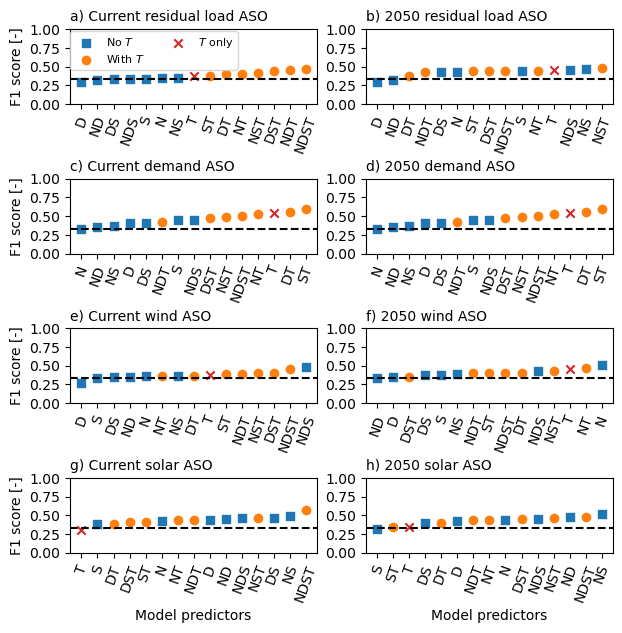

In [39]:
plot_score_by_season(results, future_results, "NEM")

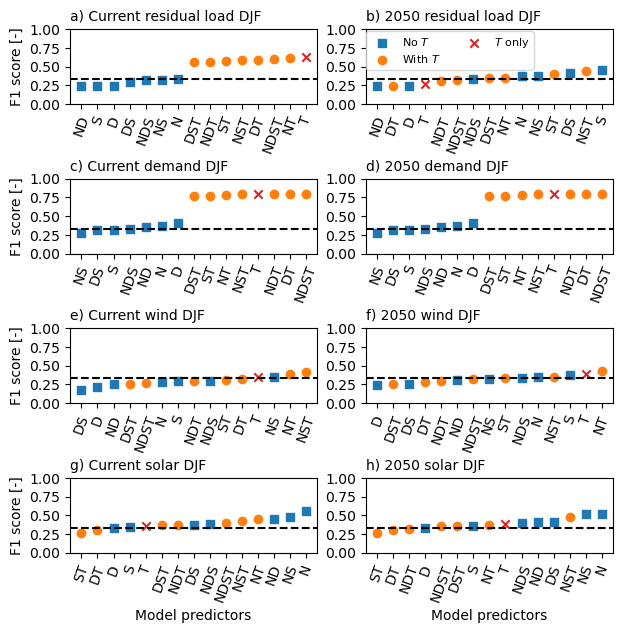

In [40]:
plot_score_by_season(results, future_results, "NEM", season="DJF", legend_col=1)